# 🔊 Notebook 2: Decibels, SNR, and Realistic Noise Synthesis
### *How to synthesize realistic noise and mix audio at exact SNR levels (Google Colab Ready)*

In real world communications (smartphones, Zoom, gaming headsets), microphones capture speech corrupted by environmental noise:
$$y(t) = s(t) + n(t)$$

In this notebook, we master:
1. **The Decibel (dB) Scale**: Why audio engineers use logarithmic power units.
2. **Signal-to-Noise Ratio (SNR)**: Mathematical derivation and formula.
3. **Procedural Noise Synthesis**: White noise, $1/f$ Pink noise, 60Hz Mains Hum, and Cafeteria Babble.
4. **Dynamic Mixing**: Scaling noise to achieve exact desired SNRs (e.g. -5 dB, 0 dB, +10 dB).

> ⚡ **Standalone & Colab Ready**: All DSP and noise generators are defined directly in this notebook!


In [10]:
!unzip -q data.zip

replace data/outputs/noisy_test.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
# 🚀 Google Colab Setup (Runs everywhere: Colab, Kaggle, Local)
# Install required audio libraries silently if not already installed
!pip install -q soundfile librosa matplotlib torch ipython

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import IPython.display as ipd
from IPython.display import display
import torch

# Clean dark-themed visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")


PyTorch Version: 2.11.0+cu128 | CUDA Available: True


In [12]:
# ==============================================================================
# Standalone Audio & DSP Functions (Zero 'src' dependencies)
# ==============================================================================

def generate_synthetic_speech(duration=3.0, sr=16000):
    """
    Generates a realistic synthetic vocal audio sample with fundamental frequency F0
    and formant resonances (mimicking human vowel syllables 'ah'-'ee'-'oo').
    Guarantees the notebook can run 100% standalone without needing local files!
    """
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    # Pitch contour F0: gentle vibrato around 140 Hz (human voice pitch)
    f0 = 140.0 + 8.0 * np.sin(2 * np.pi * 3.5 * t)
    phase = 2 * np.pi * np.cumsum(f0) / sr

    # Glottal source: impulse-like harmonic buzz
    source = np.sin(phase) + 0.5 * np.sin(2 * phase) + 0.3 * np.sin(3 * phase) + 0.2 * np.sin(4 * phase)

    # Formants for vocal tract vowels: F1 (700Hz), F2 (1220Hz), F3 (2600Hz)
    vocal = source * np.sin(2 * np.pi * 700 * t) + 0.5 * source * np.sin(2 * np.pi * 1220 * t) + 0.25 * source * np.sin(2 * np.pi * 2600 * t)

    # Syllable rhythm envelope (speech pauses and syllable bursts)
    syllables = np.maximum(0.0, np.sin(2 * np.pi * 1.8 * t)) ** 2
    speech = vocal * syllables

    # Normalize to [-0.9, 0.9]
    speech = speech / (np.max(np.abs(speech)) + 1e-8) * 0.9
    return speech.astype(np.float32)

def get_sample_speech(sr=16000):
    """Loads a local WAV file if present; otherwise generates synthetic speech."""
    search_paths = [
        "content/data/clean_speech/*.wav",
        "data/clean_speech/*.wav",
        "../../data/clean_speech/*.wav"
    ]
    for pattern in search_paths:
        matches = glob.glob(pattern)
        if matches:
            wav, _ = librosa.load(matches[0], sr=sr, mono=True)
            return wav.astype(np.float32)

    print("ℹ️ No local WAV file found. Using high-fidelity synthetic speech sample.")
    return generate_synthetic_speech(duration=3.0, sr=sr)

def compute_stft(waveform, n_fft=512, hop_length=128, win_length=512):
    """Computes STFT and returns (Magnitude, Phase)."""
    window = np.hanning(win_length)
    stft_matrix = librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
    magnitude = np.abs(stft_matrix).astype(np.float32)
    phase = np.angle(stft_matrix).astype(np.float32)
    return magnitude, phase

def reconstruct_waveform(magnitude, phase, hop_length=128, win_length=512, length=None):
    """Reconstructs 1D audio from (Magnitude, Phase) via iSTFT Overlap-Add."""
    complex_spec = magnitude * np.exp(1j * phase)
    window = np.hanning(win_length)
    waveform = librosa.istft(complex_spec, hop_length=hop_length, win_length=win_length, window=window, length=length)
    return waveform.astype(np.float32)

def mag_to_db(magnitude, top_db=80.0):
    """Converts linear magnitude to decibels for visualization."""
    mag_clamped = np.maximum(magnitude, 1e-6)
    ref = np.max(mag_clamped)
    db = 20.0 * np.log10(mag_clamped / (ref + 1e-8))
    return np.maximum(db, -top_db)


In [13]:
# ==============================================================================
# Standalone Noise Synthesis & SNR Mixing Functions
# ==============================================================================

def calculate_power(signal):
    """Calculates average power: P = mean(x^2)."""
    return float(np.mean(signal ** 2))

def calculate_snr(clean_signal, noisy_signal):
    """Calculates SNR (dB): 10 * log10(P_clean / P_noise)."""
    noise = noisy_signal - clean_signal
    p_clean = calculate_power(clean_signal)
    p_noise = calculate_power(noise)
    if p_noise <= 1e-12:
        return 100.0
    return float(10.0 * np.log10((p_clean + 1e-12) / p_noise))

def mix_at_snr(clean, noise, target_snr_db):
    """
    Scales noise to achieve exact target SNR (dB):
    alpha = sqrt( P_clean / (P_noise * 10^(SNR/10)) )
    y = clean + alpha * noise
    """
    clean = clean.astype(np.float32)
    noise = noise.astype(np.float32)

    # Loop noise if shorter than clean
    if len(noise) < len(clean):
        repeats = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeats)[:len(clean)]
    else:
        noise = noise[:len(clean)]

    p_clean = calculate_power(clean)
    p_noise = calculate_power(noise)

    if p_noise < 1e-12:
        return clean, noise, 100.0

    target_ratio = 10.0 ** (target_snr_db / 10.0)
    alpha = np.sqrt(p_clean / (p_noise * target_ratio))
    scaled_noise = alpha * noise
    noisy = clean + scaled_noise

    # Avoid clipping
    max_val = np.max(np.abs(noisy))
    if max_val > 0.95:
        norm_factor = 0.95 / max_val
        noisy = noisy * norm_factor
        scaled_noise = scaled_noise * norm_factor

    actual_snr = calculate_snr(clean, noisy)
    return noisy, scaled_noise, actual_snr

def generate_white_noise(num_samples):
    """Generates Gaussian White Noise (flat power spectrum)."""
    return np.random.randn(num_samples).astype(np.float32)

def generate_pink_noise(num_samples):
    """Generates Pink Noise (1/f power drop: rain, waterfall, wind)."""
    white = np.random.randn(num_samples)
    fft = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(num_samples)
    freqs[0] = 1e-6
    fft_pink = fft / np.sqrt(freqs)
    pink = np.fft.irfft(fft_pink, n=num_samples)
    return (pink / (np.max(np.abs(pink)) + 1e-8)).astype(np.float32)

def generate_hum_noise(num_samples, sr=16000, base_freq=60.0):
    """Generates 60 Hz electrical mains hum with odd harmonics."""
    t = np.arange(num_samples) / sr
    hum = np.sin(2 * np.pi * base_freq * t)
    hum += 0.5 * np.sin(2 * np.pi * (base_freq * 2) * t)
    hum += 0.3 * np.sin(2 * np.pi * (base_freq * 3) * t)
    hum += 0.15 * np.sin(2 * np.pi * (base_freq * 5) * t)
    return (hum / (np.max(np.abs(hum)) + 1e-8)).astype(np.float32)

def generate_babble_noise(num_samples, sr=16000, num_speakers=4):
    """Simulates cafeteria background babble by overlaying pitch-shifted tones."""
    t = np.arange(num_samples) / sr
    babble = np.zeros(num_samples, dtype=np.float32)
    pitches = [110, 160, 210, 260]
    for p in pitches[:num_speakers]:
        f = p + 15.0 * np.sin(2 * np.pi * 1.2 * t)
        phase = 2 * np.pi * np.cumsum(f) / sr
        sig = np.sin(phase) * (np.maximum(0, np.sin(2 * np.pi * 3 * t)) ** 2)
        babble += sig
    return (babble / (np.max(np.abs(babble)) + 1e-8)).astype(np.float32)


## 1. Demystifying Decibels (dB) and SNR
The human ear responds logarithmically to sound power:
- $+10\text{ dB}$ means sound power is $10\times$ higher (perceived as roughly twice as loud).
- $+20\text{ dB}$ means $100\times$ higher power.

The **Signal-to-Noise Ratio (SNR)** formula:
$$\text{SNR}_{\text{dB}} = 10 \log_{10}\left( \frac{P_{\text{speech}}}{P_{\text{noise}}} \right)$$
Where signal power is the mean squared amplitude: $P = \frac{1}{N} \sum x[t]^2$.


In [14]:
# Load clean speech
sr = 16000
clean_speech = get_sample_speech(sr=sr)
num_samples = len(clean_speech)

p_speech = calculate_power(clean_speech)
print(f"Clean speech duration: {num_samples/sr:.2f}s | Power: {p_speech:.6f}")


Clean speech duration: 8.83s | Power: 0.003466


## 2. Generating the 4 Major Types of Noise
Let's synthesize 4 distinct noise profiles:
1. **White Noise**: Flat frequency spectrum. Radio static.
2. **Pink Noise**: $1/f$ spectrum (energy drops 3 dB per octave). Steady rain, wind.
3. **60 Hz Power Hum**: Mains hum + harmonic overtones. Ground loop, HVAC motors.
4. **Babble Noise**: Multi-speaker background voices. Coffee shop cocktail party.


In [15]:
white_noise = generate_white_noise(num_samples)
pink_noise = generate_pink_noise(num_samples)
hum_noise = generate_hum_noise(num_samples, sr=sr, base_freq=60.0)
babble_noise = generate_babble_noise(num_samples, sr=sr, num_speakers=4)

print("Synthesized 4 noise sources successfully!")


Synthesized 4 noise sources successfully!


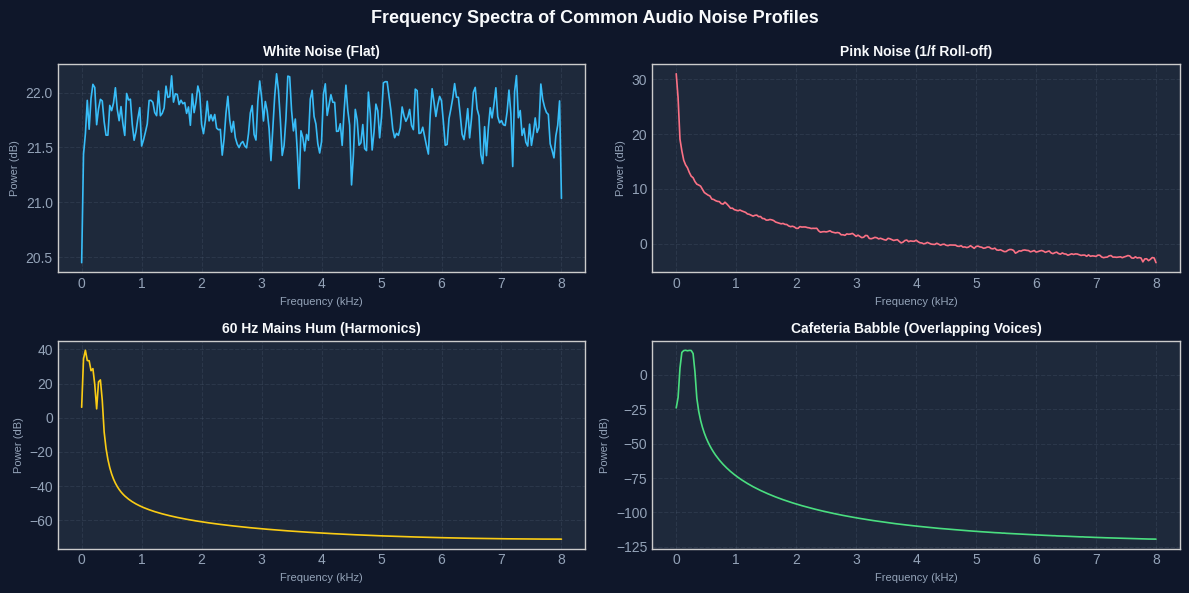

In [16]:
# Compare the Power Spectra of Noise Types
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.patch.set_facecolor('#0f172a')

noise_dict = {
    "White Noise (Flat)": (white_noise, axes[0, 0], '#38bdf8'),
    "Pink Noise (1/f Roll-off)": (pink_noise, axes[0, 1], '#fb7185'),
    "60 Hz Mains Hum (Harmonics)": (hum_noise, axes[1, 0], '#facc15'),
    "Cafeteria Babble (Overlapping Voices)": (babble_noise, axes[1, 1], '#4ade80')
}

for title, (n_data, ax, color) in noise_dict.items():
    ax.set_facecolor('#1e293b')
    mag, _ = compute_stft(n_data)
    mean_spectrum = np.mean(mag, axis=1)
    freqs = np.linspace(0, sr / 2000, len(mean_spectrum))
    ax.plot(freqs, 20*np.log10(mean_spectrum + 1e-6), color=color, linewidth=1.2)
    ax.set_title(title, color='#f8fafc', fontsize=10, fontweight='bold')
    ax.set_xlabel("Frequency (kHz)", color='#94a3b8', fontsize=8)
    ax.set_ylabel("Power (dB)", color='#94a3b8', fontsize=8)
    ax.tick_params(colors='#94a3b8')
    ax.grid(True, linestyle='--', alpha=0.2, color='#64748b')

plt.suptitle("Frequency Spectra of Common Audio Noise Profiles", color='#f8fafc', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Mixing Speech and Noise at Configurable SNR
To achieve an exact target SNR, we compute the scaling factor:
$$\alpha = \sqrt{\frac{P_{\text{speech}}}{P_{\text{noise}} \cdot 10^{\text{SNR}_{\text{target}} / 10}}}$$
$$y(t) = s(t) + \alpha \cdot n(t)$$
Let's create audio mixtures at $+10\text{ dB}$, $0\text{ dB}$, and $-5\text{ dB}$:


In [17]:
snr_levels = [10.0, 0.0, -5.0]
mixtures = {}

for target_snr in snr_levels:
    noisy, scaled_noise, actual_snr = mix_at_snr(clean_speech, pink_noise, target_snr_db=target_snr)
    mixtures[target_snr] = (noisy, actual_snr)
    print(f"Target SNR: {target_snr:+5.1f} dB | Measured SNR: {actual_snr:+5.2f} dB")


Target SNR: +10.0 dB | Measured SNR: +10.00 dB
Target SNR:  +0.0 dB | Measured SNR: -0.00 dB
Target SNR:  -5.0 dB | Measured SNR: -5.00 dB


In [18]:
# Audio Listening Test across SNR levels
print("1. Clean Reference Speech:")
display(ipd.Audio(clean_speech, rate=sr))

print("2. Mild Noise (+10 dB SNR) - Speech clearly audible:")
display(ipd.Audio(mixtures[10.0][0], rate=sr))

print("3. Equal Power (0 dB SNR) - Speech struggling against noise:")
display(ipd.Audio(mixtures[0.0][0], rate=sr))

print("4. Severe Noise (-5 dB SNR) - Noise 3.16x more powerful than speech:")
display(ipd.Audio(mixtures[-5.0][0], rate=sr))


1. Clean Reference Speech:


2. Mild Noise (+10 dB SNR) - Speech clearly audible:


3. Equal Power (0 dB SNR) - Speech struggling against noise:


4. Severe Noise (-5 dB SNR) - Noise 3.16x more powerful than speech:
